# Tests de primalité

In [1]:
import time
import math
import numpy as np
import secrets
import matplotlib.pyplot as plt


# Objectif

L'objectif des tests de primalité est de **déterminer si un nombre est premier**.

# Importance des nombres premiers


Écrire...

Complexité du problème (ici?) Lien avec factorisation.
Pourquoi utiliser ces tests? -> Générer des nombres premiers.

# Méthodes **Déterministes** Simples

## Test de division

Cette méthode naïve consiste à tester **si l'entier n est divisible par un nombre $<n$**. Si oui, alors n n'est pas premier. Sinon, n est premier.

In [2]:
def test_de_division_1(n):
    """Cette fonction teste si un entier est premier de manière naïve. 

    Méthode: Il divise n par chaque entier entre 2 et n-1. Si le reste de la division est zéro, nous avons trouvé un diviseur (témoin) de n.
    Alors, le nombre n n'est pas premier.
    
    Input:
        - n: entier
    Output: boolean
        - True: si n est un premier
        - False: si n n'est pas premier
    """

    for i in range(2,n): # range n'inclut pas la bonne supérieure
        if (n%i==0):
            print(f"{n} divisible par {i}")
            return False
    return True



In [3]:
#Quelques tests:
print("5 est un nombre premier? ->", test_de_division_1(5))
print("----------------------------------------------------------------------------")
print("31 est un nombre premier? ->", test_de_division_1(31))
print("----------------------------------------------------------------------------")
print("64 est un nombre premier? ->", test_de_division_1(64))
print("----------------------------------------------------------------------------")

#Et pour des nombres plus grands?
print("198652303567655 est un nombre premier? -> ", test_de_division_1(198652303567655))
print("----------------------------------------------------------------------------")
print("19865256234567898765432345672834345672317654345609876598765434567 est un nombre premier? ->", test_de_division_1(19865256234567898765432345672834345672317654345609876598765434567))


#En pratique les nombres premiers utilisés sont très grands: module de 2048 bits et chaque premier d'environ 1024 bits

print("----------------------------------------------------------------------------")
n=secrets.randbelow(2**1024 - 2**1000 + 1) + 2**1000 |1  #Générer un nombre aléatoires entre 2**1000 et 2**1024
print(f"{n} premier? ->\n ", test_de_division_1(n))

#Le problème se pose si le nombre est vraiment un nombre premier: Alors, nous testons réellement tous les diviseurs possibles.
m= 110128273333447923057212596552694517934592411368681123517539719232555954780356742517508963819591093833847720270284002600827123019921543348656380011144975918357425611997473213561060582023921227278009685742577854263011026130835833121778103465966947922533508900301709422268004705270813439133974919242891119636573
#print(f"{m} prime? -> \n", test_de_division_1(m))


tests_values=[5, 31, 64,19865256234567898765432345672834345672317654345609876598765434567, n]


5 est un nombre premier? -> True
----------------------------------------------------------------------------
31 est un nombre premier? -> True
----------------------------------------------------------------------------
64 divisible par 2
64 est un nombre premier? -> False
----------------------------------------------------------------------------
198652303567655 divisible par 5
198652303567655 est un nombre premier? ->  False
----------------------------------------------------------------------------
19865256234567898765432345672834345672317654345609876598765434567 divisible par 3
19865256234567898765432345672834345672317654345609876598765434567 est un nombre premier? -> False
----------------------------------------------------------------------------
15401603684155403725941884575145870582734032388316247071003642893848895482170826797692317762386881719163569452766468003458411288246595043277103258107575216027689139421155307571290918054692989170342427319078591389627926043429843014967

NB: En pratique, les nombres premiers utilisés sont très grands: module de 2048 bits (par exmple) et chaque premier d'environ 1024 bits.


Remarques:
- Ce test est efficace pour de petits nombres.
- Il fonctionne également pour des grands nombres qui sont "clairement" non-premiers, car le test trouvera très rapidement un diviseur (témoin). Par exemple: des nombres pairs, et n dans les exemples ci-dessus (divisible par 5).
- En revanche, il n'est pas raisonnable de l'utiliser pour tester des grands nombres premiers (comme m). Dans ce cas-là, le code va tester tous les nombres $<n$ et prendra un temps immesurable. **Nous en concluons que ce test n'est pas utilisable en pratique (lorsque nous cherchons à tester et générer des grands nombres premiers).**


## Test de division "amélioré"

En réalité, dans le test ci-dessus, nous pouvons considérer uniquement les nombres jusqu'à $\sqrt{n}$.

En effet, si un nombre n est composite, il peut s'écrire $n=a\cdot b$. Supposons par l'absurde que $a>\sqrt{n}$ et $b>\sqrt{n}$. Alors:

> $a\cdot b > \sqrt{n} \cdot \sqrt{n} = n$

une contradiction. 

Donc : au moins un des deux facteurs est $\leq \sqrt{n}$.

In [4]:
def test_de_division_2(n):
    """ 
    Cette fonction teste si un entier n est premier de manière naïve. 

    Méthode: Il divise n par chaque entier entre 2 et sqrt{n}. Si le reste de la division est zéro, nous avons trouvé un diviseur (témoin) de n.
    Alors, le nombre n n'est pas premier.
    
    Input:
        - n: entier
    Output: boolean
        - True: si n est un premier
        - False: si n n'est pas premier
    
    
    """

    for i in range(2,math.ceil(math.sqrt(n))):
        if (n%i==0):
            print(f"{n} divisible par {i}")
            return False
    return True
    
    

In [5]:
#Tests:

for i in tests_values:
    print(f"{i} est un nombre premier? ->", test_de_division_2(i))
    print("----------------------------------------------------------------------------")




5 est un nombre premier? -> True
----------------------------------------------------------------------------
31 est un nombre premier? -> True
----------------------------------------------------------------------------
64 divisible par 2
64 est un nombre premier? -> False
----------------------------------------------------------------------------
19865256234567898765432345672834345672317654345609876598765434567 divisible par 3
19865256234567898765432345672834345672317654345609876598765434567 est un nombre premier? -> False
----------------------------------------------------------------------------
154016036841554037259418845751458705827340323883162470710036428938488954821708267976923177623868817191635694527664680034584112882465950432771032581075752160276891394211553075712909180546929891703424273190785913896279260434298430149675158393534886461783240046803355770771414596899247739854513916610100121059673 divisible par 7
15401603684155403725941884575145870582734032388316247071003642893

## Méthode avec Crible D'Eratosthène

Le crible d'Eratosthène permet de **trouver tous les nombres premiers plus petits qu'un entier n**.

Cet algorithme procède par élimination. Il supprime d'une table contenant les entiers de 2 à *n* tous les multiples d'un entier (autres que le nombre lui-même).

Par exemple, il commence par supprimer les multiples de 2, puis les multiples de 3 restants, les multiples de 5 restants, etc. 

L'algorithme commence toujours l'étape suivante avec le plus petit entier non-éliminé *m* qui n'a pas encore été considéré. Nous savons que ce nombre *m* est premier, car il n'a pas été éliminé précédemment. Il procède en éliminant ses multiples en commençant par $m^2$. En effet, comme expliqué précédemment, si un nombre *n* est composé, alors au moins un de ses facteurs est plus petit que $\sqrt{n}$. (Cependant, les élément plus petits que *m* ont déjà été traités). C'est pourquoi pour chaque premier *m* trouvé, nous commençons l'élimination à $m^2$.

L'algorithme s'arrête lorsque le carré du plus petit entier restant *m* est supérieur au plus grand entier restant. Alors, tous les nombres non-premiers ont été éliminés de la liste dans les étapes précédentes.

Complexité de l'algorithme: ... et combiné avec division



In [6]:
%pip install bitarray
from bitarray import bitarray

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
def crible_dEratosthene(n):
    """ 
    Cette fonction implémente le crible d'Eratosthène. Cette méthode permet de trouver tous les nombres premiers plus petits qu'un entier n.

    NB: Cette implémentation utilise un numpy array de booléens.

    Input:
        - n: entier
    Output: 
        - 
    """
    valeurs = bitarray(n+1) #On choisit d'utiliser un numpy array de taille n+1 pour avoir des indices entre 0 et n (sinon on doit tout décaler pour avoir de 1 à n)
    valeurs.setall(True)
    valeurs[0]=not valeurs[0]  #Les bitarray se comportent comme des booléens en Python.
    valeurs[1]=not valeurs[1]
    
    for i in range(2,n+1): #range(2,n+1) car range n'inclut pas la borne du haut.
        if valeurs[i] and i**2<=n:
            for j in range(i**2, n+1, i):
                if valeurs[j]:
                    valeurs[j]=not valeurs[j]
        if i**2>n:
            break

    return list(valeurs.search(1))



def test_de_division_3(n):
    """ Cette fonction teste si un entier n est premier en combinant le test de division et le crible d'Eratosthène.

    Méthode: Génère les nombres premiers plus petits que sqrt{n} et teste si un d'entre eux est un diviseur de n. Si oui, n n'est pas premier.
    Sinon, n est premier.

    Input:
        - n: entier
    Output: boolean
        - True: si n est un premier
        - False: si n n'est pas premier
    
    """
    nb_premiers=crible_dEratosthene(math.ceil(math.sqrt(n))) #Cherche les nombres premiers plus petits que sqrt{n}
    
    for i in nb_premiers:
        if (n%i==0):
            print(f"{n} divisible par {i}")
            return False
        
    return True



In [8]:
#Test cribles:

print(crible_dEratosthene(31))

[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31]


In [9]:
#Tests
tests_values=[15,31,64,81,101, 871, 1000000023, 432456782934]
for i in tests_values:
    print(f"{i} est un nombre premier? ->", test_de_division_3(i))
    print("----------------------------------------------------------------------------")



15 divisible par 3
15 est un nombre premier? -> False
----------------------------------------------------------------------------
31 est un nombre premier? -> True
----------------------------------------------------------------------------
64 divisible par 2
64 est un nombre premier? -> False
----------------------------------------------------------------------------
81 divisible par 3
81 est un nombre premier? -> False
----------------------------------------------------------------------------
101 est un nombre premier? -> True
----------------------------------------------------------------------------
871 divisible par 13
871 est un nombre premier? -> False
----------------------------------------------------------------------------
1000000023 divisible par 3
1000000023 est un nombre premier? -> False
----------------------------------------------------------------------------
432456782934 divisible par 2
432456782934 est un nombre premier? -> False
-----------------------------

Remarques:
- Pour des grandes valeurs de n, nous atteignons des limites de mémoires également (non seulement calculatoires) et de représentation des indices de tableaux.
- Les bitarrays permettent de diminuer l'espace occupé en mémoire mais ils ne résolvent pas le problème de représentation des indices.
- Il faudrait trouver une solution pour ne pas devoir générer tout à l'avance. 
- Ils existent des méthodes qui travaillent en pipeline, mais elles nécessitent des machines parallèles pour être réellement efficaces.

# Tests probabilistes

Les tests probabilistes (type Monte-Carlo) se basent sur une propriété/identité qui doit être satisfaite par un nombre premier. L'idée de base pour vérifier la primalité de *n* est la suivante:
1. Tirer un nombre aléatoire *a*.
2. Vérifier une propriété/identité faisant intervenir *a* et *n* et qui est satisfaite si *n* est premier. Si l'identité n'est pas satisfaite, alors *n* est nécessairement composé et le test s'arrête. Alors, *a* est appelé un *témoin*.
3. Sinon, répéter les étapes précédentes jusqu'à atteindre le taux d'erreur demandé. Après le nombre choisi d'itérations, si *n* n'est pas détecté comme composé, il est déclaré *probablement premier*.

Ces méthodes sont de type Monte-Carlo. **Elles ne garantissent pas qu'un nombre déclaré premier soit réellement premier, mais un nombre déclaré non-premier l'est forcément** (ie. faux-positif, mais pas de faux négatif). Cependant, il est généralement possible de rendre la **probabilité d'erreur aussi petite que souhaitée**.

Malheureusement, selon le test, il existe des nombres composés qui sont toujours déclarés probablement premiers (eg. les nombres de Carmichael pour le test de Fermat - voir plus bas). Ces nombres sont appelés **nombres pseudopremiers** pour ce test. 

Même s'ils ne garantissent pas la primalité d'un nombre, ces tests sont d'excellents candidats pour les applications cryptographiques de part leur coût faible en temps de calcul.


NB: Il existe d'autres types de tests probabilistes: les tests de type Las Vegas. Ceux-ci assurent qu'un nombre déclaré premier est réellement premier, mais peuvent déclarer non-premier certains nombres premiers (ie. pas de faux-positifs, mais des faux négatifs). Ils sont également très utilisés.

## Test de Fermat

Le test de Fermat est un **test de primalité probabiliste de type Monte-Carlo**. Il se base sur le **petit théorème de Fermat** (et surtout sur sa contraposée):

Théorème:
> Si p est un nombre premier, alors $\forall 1\leq a< p, a^{p-1} \equiv 1 \mod p$ (ie. $a^{p-1}-1$ est divisible par p).

Contraposée:
> S'il existe $1\leq a<p$ tel que $a^{p-1}\not\equiv 1 \mod p$, alors p n'est pas premier.



Attention: Pour un *a* fixe, il est possible que $a^{p-1}\equiv 1\mod p$ **sans que p soit premier**. Un tel *p* est alors dit *pseudo-premier de Fermat* de base *a*. Un nombre *p* qui est pseudo-premier pour toute base *a* telle que *a* est premier avec *p* est appelé un **nombre de Carmichael**. Malheureusement, il existe une infinité de tels nombres. C'est un des points faibles du test de Fermat. 



Le test de Fermat se base donc sur l'idée que si *p* est composé, alors il est peu probable que $a^{p-1}\equiv 1\mod p$ pour une valeur arbitraire de *a*. Pour tester la primalité d'un nombre *n*, il procèdera donc de la manière suivante:
1. Choisir un entier positif $a<n$ aléatoirement.
2. Tester si $a^{n-1}\equiv 1\mod n$. Si ce n'est pas le cas, alors nous sommes sûr que *n* n'est pas premier: le test s'arrête et renvoie False.
3. Sinon, répéter les étapes ci-dessus jusqu'à atteindre le taux d'erreur souhaité (choisir le nombre d'itérations en fonction du taux d'erreur souhaité).


Taux d'erreur:
Il y a deux bonnes nouvelles:

- La probabilité que le résultat soit erroné pour un entier *n* tend vers 0 quand le nombre de bits de *n* tend vers l'infini. Bien entendu, nous ne disposons pas de nombre arbitrairement grands sur un ordinateur. Cependant, ce résultat est rassurant, d'autant que nous travaillons avec des nombres très grands dans ce contexte.
- La probabilité que le résultat soit erroné au bout de k itérations est de $1/2^k$.



In [10]:
def test_de_fermat(n,nb_tests=100):
    """Cette fonction implémente un test de Fermat itéré.

    Méthode: 
    1. Choisir un nombre aléatoire a<n
    2. Vérifier que a^{n-1} congru 1 mod p
        Si ce n'est pas le cas: retourner Faux
    3. Sinon recommencer
    
    Input:
        - n: entier (dont nous voulons vérifier la primalité)
        - nb_tests: entier -> nombre d'itérations à effectuer
    Output: boolean
        - False: Si n n'est pas premier
        - True: Si n est probablement premier
    
    """

    test_a=np.array([secrets.randbelow(n-1) for _ in range(nb_tests)])+1 #Générer les valeurs de a


    restes=np.array([pow(int(x), n-1, n) for x in test_a]) #Calcul a^(n-1) mod p

    if np.all(restes == 1):
        return True
    else:
        return False



In [11]:
#m est un très grand nombre premier 
m=110128273333447923057212596552694517934592411368681123517539719232555954780356742517508963819591093833847720270284002600827123019921543348656380011144975918357425611997473213561060582023921227278009685742577854263011026130835833121778103465966947922533508900301709422268004705270813439133974919242891119636573
tests_values=[15,31,64,81,101, 871, 1000000023, 432456782934,n,m]


for v in tests_values:
    print(f"{v} est un nombre premier?->", test_de_fermat(v))


#Exemples de nombres de Carmichael
carmichael=[561, 1105, 1729, 2465,2821, 6601,8911] #7 premiers nombres de Carmichael

for v in carmichael:
    print(f"{v} est un nombre premier?->", test_de_fermat(v))

15 est un nombre premier?-> False
31 est un nombre premier?-> True
64 est un nombre premier?-> False
81 est un nombre premier?-> False
101 est un nombre premier?-> True
871 est un nombre premier?-> False
1000000023 est un nombre premier?-> False
432456782934 est un nombre premier?-> False
154016036841554037259418845751458705827340323883162470710036428938488954821708267976923177623868817191635694527664680034584112882465950432771032581075752160276891394211553075712909180546929891703424273190785913896279260434298430149675158393534886461783240046803355770771414596899247739854513916610100121059673 est un nombre premier?-> False
110128273333447923057212596552694517934592411368681123517539719232555954780356742517508963819591093833847720270284002600827123019921543348656380011144975918357425611997473213561060582023921227278009685742577854263011026130835833121778103465966947922533508900301709422268004705270813439133974919242891119636573 est un nombre premier?-> True
561 est un nombre premier?-> 

## Test de Miller-Rabin

Le test de Miller-Rabin est **un test de primalité probabiliste de type Monte-Carlo**.

Ce test se base à nouveau sur une propriété de l'entier *n*, dépendant d'un entier auxiliaire *a*, qui est vraie si *n* est un nombre premier. L'idée est de vérifier cette propriété pour suffisamment de valeurs de *a*.

Le test se base sur un "raffinement" du petit théorème de Fermat et le fait que dans un *corps* ($\mathbb{Z}/p\mathbb{Z}$ est un corps si p est premier), l'équation $X^2=1$ n'a que 1 et -1 pour solutions. Par le théorème de Fermat, nous pouvons déduire la proposition suivante:

Proposition: Soit $p>2$ un nombre premier, *s* et *d* les deux entiers naturels, *s* non nul et *d* impair, tels que $p-1=2^s\cdot d$ (ie. *s* est le nombre maximum de fois que nous pouvons mettre 2 en facteur de $p-1$). Alors, pour tout **entier a non divisible par p**:
> $a^d\equiv 1 \mod p$ ou $\exists r\in\{0,1,...,s-1\} \text{ tel que }a^{2^rd}\equiv -1 \mod p$


En effet, le petit théorème de Fermat nous dit:
> $a^{p-1}=(a^{d})^{2^s}\equiv 1 \mod p$

En prenant de façon répétée les racines carrées, nous obtenons soit toujours $1\mod p$ jusqu'à $a^d\equiv 1 \mod p$, soit pour un $0\leq r<s, a^{d2^r}\equiv -1 \mod p$ seule autre racine carré possible.

La contraposée nous dit:

Contraposée:
> Si $a^d\not\equiv 1\mod p$ et $\forall r\in\{0,1,...,s-1\}, a^{2^rd}\not\equiv -1 \mod p$, alors p est composé. *a* est appelé un *témoin de Miller*.



Attention: Pour un *a* fixe, il est possible que la conclusion de la proposition soit satisfaite. Tout comme pour Fermat, certains témoins peuvent satisfaire la propriété même si *n* n'est pas premier. Cependant, l'avantage du test de Miller comparé au test de Fermat est qu'un nombre composé possède toujours au moins un témoin qui ne satisfait pas la propriété, c'est-à-dire que l'équivalent des nombres de Carmichael n'existe pas pour le test de Miller-Rabin.

De plus:

Proposition:
> Pour un nombre impair composé *n*, au moins 3/4 des entiers $1<a<n$ sont des témoins de Miller pour *n*.

En répétant le test pour un nombre suffisamment grands d'entiers *a*, nous pouvons rendre la probabilité d'erreur aussi faible que nécessaire.


Ainsi, le test de Miller-Rabin procède de la façon suivante:
1. Choisir un entier $1<a<n$.
2. Tester si *a* satisfait la propriété de la proposition. Si ce n'est pas le cas, nous avons trouvé un témoin de Miller. Le test s'arrête et renvoie False.
3. Sinon, répéter les étapes ci-dessus suffisamment de fois pour atteindre le taux d'erreur espéré.

Pour déterminer si *a* est un témoin de Miller, nous effectuons les opérations suivantes:
1. Calculer les entiers *s* et *d* de la proposition.
2. Vérifier si $x=a^d \mod n$ est égal à $1\mod p$ ou $-1\mod p\equiv n-1$. Si c'est le cas, alors nous pouvons nous arrêter car *a* n'est pas un témoin de Miller.
3. Sinon, répéter s-1 fois le calcul $x=x^2\mod n$ (avec comme valeur de départ pour x, la valeur calculée au point précédent) et vérifier si $x\equiv -1 \mod n \equiv n-1$. Si c'est le cas, alors *a* n'est pas un témoin de Miller.
4. Si nous effectuons les s-1 étapes sans sortir de la fonction, alors *a* n'a satisfait aucune des propriétés dans la conclusion de la proposition et *a* est donc un témoin de Miller.


Cet algorithme est très utilisé en pratique en cryptographie, en particulier en cryptographie asymétrique pour générer des grands nombres premiers, nécessaires par exemple pour le chiffrement asymétrique RSA.


Taux d'erreur:
- Tout comme pour le test de Fermat, il est possible de rendre la probabilité d'une réponse erronée aussi petite que souhaitée en choisissant le nombre d'itérations de manière appropriée.


Complexité?

In [26]:
def calcul_decomposition(v):
    """Cette fonction détermine les valeurs de s et d de la proposition.
    
    Input:
        - v: entier
    Output:
        - (s,d): tuple
    
    """
    reste=v
    s=0

    while reste%2==0: 
        s+=1
        reste//=2
    return s, reste
    



def temoin_de_miller(n,a,s,d):
    """Cette fonction vérifie si l'entrée a est un témoin de Miller pour l'entier n.

    Méthode:
        L'idée générale est de vérifier les propriétés de la proposition:
        1. Vérifier si a^d mod p=1 ou -1 
        2. Vérifier si a^{d2^r} mod p=-1 pour un certain r
    
    Input:
        - n: entier -> entier dont nous voulons déterminer la primalité
        - a: entier -> entier dont nous voulons déterminer s'il est témoin de Miller
        - s,d : entiers -> entiers décomposant n en 2^sd.
    Output:
        - True: si a est un témoin de Miller
        - False: si a n'est pas un témoin de Miller (ie. satisfait une des propriétés de la proposition)

    """
    
    x=pow(a, d, n)
    if x==1 or x==n-1: #Vérifier
        return False
    
    for _ in range(s-1):
        x=pow(x,2,n)
        if x==n-1:
            return False
    
    return True



def miller_rabin(n,nb_test=100):
    """ Cette fonction implémente un test de Miller-Rabin (itéré).
    
    Méthode:
        - Choisir un nombre 1<a<n aléatoirement.
        - Vérifier les propriétés de la proposition pour a.
    
    Input:
        - n: entier -> nombre dont nous souhaitons tester la primalité
        - nb_test: entier -> nombre d'itérations.    
    Output: boolean
        - False: si n est composé
        - True: si n est probablement premier
    """

    if n<2: #Cas de base
        return False
    
    if n%2==0 and n!=2: #Éliminer le cas pair
        return False
    
    s,d=calcul_decomposition(n-1) #Nous calculons une seule fois la décomposition


    for _ in range(nb_test):
        a=secrets.randbelow(n-2)+2 #randbelow ne comprend pas la borne supérieure spécifiée
        if temoin_de_miller(n,a,s,d):
            return False
    
    return True

#Vérifier fonctionne tout le temps.


In [27]:
#Tests:

#m est un très grand nombre premier 
m=110128273333447923057212596552694517934592411368681123517539719232555954780356742517508963819591093833847720270284002600827123019921543348656380011144975918357425611997473213561060582023921227278009685742577854263011026130835833121778103465966947922533508900301709422268004705270813439133974919242891119636573
tests_values=[15,31,64,81,101, 871, 1000000023, 432456782934,n,m]


for v in tests_values:
    print(f"{v} est un nombre premier?->", miller_rabin(v))


#Exemples de nombres de Carmichael
carmichael=[561, 1105, 1729, 2465,2821, 6601,8911] #7 premiers nombres de Carmichael

for v in carmichael:
    print(f"{v} est un nombre premier?->", miller_rabin(v))

#Tester avec la génération aléatoire comme en bas.


15 est un nombre premier?-> False
31 est un nombre premier?-> True
64 est un nombre premier?-> False
81 est un nombre premier?-> False
101 est un nombre premier?-> True
871 est un nombre premier?-> False
1000000023 est un nombre premier?-> False
432456782934 est un nombre premier?-> False
154016036841554037259418845751458705827340323883162470710036428938488954821708267976923177623868817191635694527664680034584112882465950432771032581075752160276891394211553075712909180546929891703424273190785913896279260434298430149675158393534886461783240046803355770771414596899247739854513916610100121059673 est un nombre premier?-> False
110128273333447923057212596552694517934592411368681123517539719232555954780356742517508963819591093833847720270284002600827123019921543348656380011144975918357425611997473213561060582023921227278009685742577854263011026130835833121778103465966947922533508900301709422268004705270813439133974919242891119636573 est un nombre premier?-> True
561 est un nombre premier?-> 

## Test de Solovay-Strassen

Expliquer l'algorithme.

In [14]:
def symbole_jacobi():
    """ Expliquer"""


def test_solovay_strassen(n, nb_tests=25):
    """ """
    ...

    for _ in range(nb_tests):
        a =... #Choisir a entre 2 et n-1
        x=symbole_jacobi(a,n)
        if x==0 or x!=pow(a,(n-1)/2,n):
            return False

    return True



# Tests déterministes avancés

## Test AKS

# Évaluation des performances

In [15]:
import matplotlib.pyplot as plt

[3, 97, 283, 4991, 15519, 206141, 1028505, 77682585, 657651433]
4991 divisible par 7
4991 divisible par 7
4991 divisible par 7
15519 divisible par 3
15519 divisible par 3
15519 divisible par 3
206141 divisible par 13
206141 divisible par 13
206141 divisible par 13
1028505 divisible par 3
1028505 divisible par 3
1028505 divisible par 3
77682585 divisible par 3
77682585 divisible par 3
77682585 divisible par 3


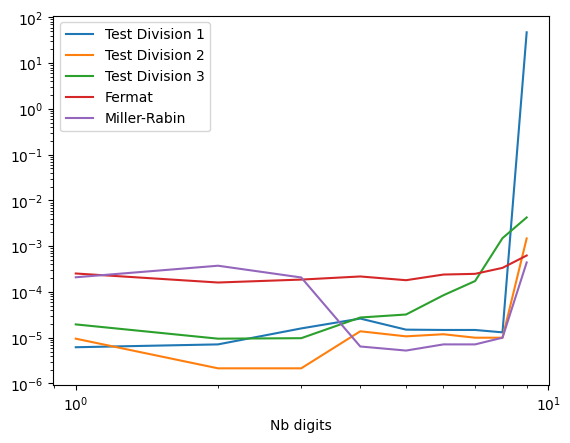

In [16]:
#Générer des valeurs tests.
values=(np.array([np.random.randint((10**i),10**(i+1)) for i in range(0,9)]) |1).tolist()
print(values)

#Calculer les temps pour chaque algorithme.
times_division_1=[]
times_division_2=[]
times_division_3=[]
times_fermat=[]
times_miller_rabin=[]

for v in values:
    start_division_1=time.time()
    test_de_division_1(v)
    end_division_1=time.time()
    times_division_1.append(end_division_1-start_division_1)

    start_division_2=time.time()
    test_de_division_2(v)
    end_division_2=time.time()
    times_division_2.append(end_division_2-start_division_2)

    start_division_3=time.time()
    test_de_division_3(v)
    end_division_3=time.time()
    times_division_3.append(end_division_3-start_division_3)

    start_fermat=time.time()
    test_de_fermat(v)
    end_fermat=time.time()
    times_fermat.append(end_fermat-start_fermat)

    start_miller_rabin=time.time()
    miller_rabin(v)
    end_miller_rabin=time.time()
    times_miller_rabin.append(end_miller_rabin-start_miller_rabin)


#Plot les temps en digits/time pour chaque méthode.
digits=np.arange(0,9)+1

plt.figure()
plt.plot(digits, times_division_1, label="Test Division 1")
plt.plot(digits, times_division_2, label="Test Division 2")
plt.plot(digits, times_division_3, label="Test Division 3")
plt.plot(digits, times_fermat, label="Fermat")
plt.plot(digits, times_miller_rabin, label="Miller-Rabin")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Nb digits")
plt.show()



# Génération de nombres premiers

Prendre un de ces tests et l'utiliser pour la génération de nombres premiers.

# Factorisation


Expliquer le lien entre primalité et factorisation et l'asymétrie des deux problèmes


Meilleur algorithme/attaque connue à ce jour: GNFS


Sur un ordinateur quantique: Shor's résout le problème de factorisation en temps polynomial


## Méthode Naïve

Sa complexité

## QFSN

## Shor's Algorithm/Algorithme de Shor

Factoriser des très grands nombres restes tout de même impossible. 

In [17]:
%pip install qiskit
%pip install qiskit.algorithms

from qiskit.algorithms import Shor
from qiskit import Aer

N = 15  # petit nombre
backend = Aer.get_backend('aer_simulator')

shor = Shor()
result = shor.factor(N)

print(result.factors)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


ModuleNotFoundError: No module named 'qiskit.algorithms'